# V1 - HOG + SVM

**Goal:** Classify plant diseases using classical feature engineering (HOG) + SVM with RBF kernel.

**Pipeline:**
```
Image (256×256) → Grayscale → Resize (64×128) → HOG Features → SVM → Prediction
```

**Output:**
- `results/models/v1_hog_svm/svm_model.pkl`
- `results/metrics/v1_metrics.json`
- `results/plots/v1_confusion_matrix.png`

## 1. Setup & Imports

In [6]:
# import os
import sys
import json
import pickle
import time
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.svm import SVC
# , LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
    #, classification_report
)

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

sns.set_style('whitegrid')
print('✅ Imports ok')
print(f'ROOT: {ROOT}')

✅ Imports ok
ROOT: /Users/marco/Documents/repos/ComputerVisionProject


## 2. Configuration

In [7]:
# ── HOG ──────────────────────────────────────────────────────────────────────
HOG_WIN_SIZE    = (64, 128)   # width × height
HOG_BLOCK_SIZE  = (16, 16)
HOG_BLOCK_STRIDE = (8, 8)
HOG_CELL_SIZE   = (8, 8)
HOG_NBINS       = 9

# ── SVM ──────────────────────────────────────────────────────────────────────
SVM_C           = 1.0
SVM_GAMMA       = 'scale'     # 1 / (n_features * X.var())
SVM_KERNEL      = 'rbf'

# ── Dataset ──────────────────────────────────────────────────────────────────
# RBF-SVM scales O(n²): for speed we subsample the train set.
# Set to None to use the whole dataset (slow ~30+ min).
MAX_TRAIN_SAMPLES = None #10_000
RANDOM_SEED       = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = ROOT / 'data' / 'processed'
MODEL_DIR   = ROOT / 'results' / 'models' / 'v1_hog_svm'
METRICS_DIR = ROOT / 'results' / 'metrics'
PLOTS_DIR   = ROOT / 'results' / 'plots'

for d in [MODEL_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'MAX_TRAIN_SAMPLES : {MAX_TRAIN_SAMPLES}')
print(f'SVM kernel        : {SVM_KERNEL}  C={SVM_C}  gamma={SVM_GAMMA}')

MAX_TRAIN_SAMPLES : None
SVM kernel        : rbf  C=1.0  gamma=scale


## 3. Dataset Loading

In [8]:
def load_paths_labels(split_dir: Path):
    """Return parallel lists (path, label_string) for one split."""
    paths, labels = [], []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                paths.append(img_path)
                labels.append(class_dir.name)
    return paths, labels

train_paths, train_labels_str = load_paths_labels(DATA_DIR / 'train')
val_paths,   val_labels_str   = load_paths_labels(DATA_DIR / 'val')
test_paths,  test_labels_str  = load_paths_labels(DATA_DIR / 'test')

# Class encoder → integers
le = LabelEncoder()
le.fit(train_labels_str)
classes = list(le.classes_)
NUM_CLASSES = len(classes)

train_labels = le.transform(train_labels_str)
val_labels   = le.transform(val_labels_str)
test_labels  = le.transform(test_labels_str)

print(f'Train : {len(train_paths):,} images')
print(f'Val   : {len(val_paths):,} images')
print(f'Test  : {len(test_paths):,} images')
print(f'Classes: {NUM_CLASSES}')

Train : 43,443 images
Val   : 5,422 images
Test  : 5,439 images
Classes: 38


## 4. HOG Feature Extraction

Each image is converted to grayscale, resized to `64×128` and processed by OpenCV's `HOGDescriptor`.

**Feature vector size:** `(block_x × block_y) × cells_per_block × nbins`
```
block_x = (64−16)/8 + 1 = 7
block_y = (128−16)/8 + 1 = 15
cells   = (16/8)² = 4
→ 7 × 15 × 4 × 9 = 3780 features/image
```

In [9]:
class HOGExtractor:
    def __init__(self):
        self.hog = cv2.HOGDescriptor(
            HOG_WIN_SIZE,
            HOG_BLOCK_SIZE,
            HOG_BLOCK_STRIDE,
            HOG_CELL_SIZE,
            HOG_NBINS
        )
        self.feature_dim = self.hog.getDescriptorSize()

    def extract(self, img_path: Path) -> np.ndarray | None:
        img = cv2.imread(str(img_path))
        if img is None:
            return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, HOG_WIN_SIZE)  # (w, h)
        features = self.hog.compute(resized)
        return features.flatten()

    def extract_batch(self, paths, desc='HOG'):
        features = np.zeros((len(paths), self.feature_dim), dtype=np.float32)
        valid_mask = np.ones(len(paths), dtype=bool)
        for i, p in enumerate(tqdm(paths, desc=desc)):
            f = self.extract(p)
            if f is not None:
                features[i] = f
            else:
                valid_mask[i] = False
        return features[valid_mask], valid_mask

extractor = HOGExtractor()
print(f'HOG feature dim: {extractor.feature_dim}')

HOG feature dim: 3780


In [10]:
# ── Subsample train (stratified) ──────────────────────────────────────────────
if MAX_TRAIN_SAMPLES and len(train_paths) > MAX_TRAIN_SAMPLES:
    sub_paths, sub_labels = resample(
        train_paths, train_labels,
        n_samples=MAX_TRAIN_SAMPLES,
        stratify=train_labels,
        random_state=RANDOM_SEED
    )
    print(f'Subsampled train: {len(sub_paths):,} images ({MAX_TRAIN_SAMPLES/len(train_paths)*100:.1f}%)')
else:
    sub_paths, sub_labels = train_paths, train_labels
    print(f'Using the full train set: {len(sub_paths):,} images')

# ── Extract features ──────────────────────────────────────────────────────────
t0 = time.time()
X_train, mask_train = extractor.extract_batch(sub_paths, desc='HOG train')
y_train = sub_labels[mask_train]
print(f'Train features: {X_train.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
X_val, mask_val = extractor.extract_batch(val_paths, desc='HOG val')
y_val = val_labels[mask_val]
print(f'Val   features: {X_val.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
X_test, mask_test = extractor.extract_batch(test_paths, desc='HOG test')
y_test = test_labels[mask_test]
print(f'Test  features: {X_test.shape}  ({time.time()-t0:.1f}s)')

Using the full train set: 43,443 images


HOG train: 100%|██████████| 43443/43443 [00:11<00:00, 3728.25it/s]


Train features: (43443, 3780)  (11.7s)


HOG val: 100%|██████████| 5422/5422 [00:01<00:00, 3622.65it/s]


Val   features: (5422, 3780)  (1.5s)


HOG test: 100%|██████████| 5439/5439 [00:01<00:00, 3179.77it/s]

Test  features: (5439, 3780)  (1.7s)


## 5. Training SVM (RBF kernel)

In [11]:
print(f'Training SVM (kernel={SVM_KERNEL}, C={SVM_C}, gamma={SVM_GAMMA}, class_weight=balanced) on {len(X_train):,} samples...')

svm = SVC(
    kernel=SVM_KERNEL,
    C=SVM_C,
    gamma=SVM_GAMMA,
    class_weight='balanced',
    random_state=RANDOM_SEED,
)

t0 = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - t0

print(f'✅ Training complete in {train_time:.1f}s ({train_time/60:.1f} min)')

# Save model
model_path = MODEL_DIR / 'svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': svm, 'label_encoder': le}, f)
print(f'Model saved: {model_path.relative_to(ROOT)}')

Training SVM (kernel=rbf, C=1.0, gamma=scale, class_weight=balanced) on 43,443 samples...
✅ Training complete in 1104.3s (18.4 min)
Model saved: results/models/v1_hog_svm/svm_model.pkl


## 6. Evaluation

In [12]:
def evaluate(model, X, y_true, split_name='Val'):
    t0 = time.time()
    y_pred = model.predict(X)
    inf_time = (time.time() - t0) / len(X) * 1000  # ms/image

    acc       = accuracy_score(y_true, y_pred)
    prec_w    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w     = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_w      = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_m    = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_m     = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_m      = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm        = confusion_matrix(y_true, y_pred)

    print(f'─── {split_name} ───────────────────────')
    print(f'  Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision (wgt) : {prec_w:.4f}   |  (macro): {prec_m:.4f}')
    print(f'  Recall    (wgt) : {rec_w:.4f}   |  (macro): {rec_m:.4f}')
    print(f'  F1        (wgt) : {f1_w:.4f}   |  (macro): {f1_m:.4f}')
    print(f'  Inf. time       : {inf_time:.3f} ms/img')

    return {
        'accuracy': float(acc),
        'precision': float(prec_w), 'recall': float(rec_w), 'f1': float(f1_w),
        'precision_macro': float(prec_m), 'recall_macro': float(rec_m), 'f1_macro': float(f1_m),
        'inference_ms_per_image': float(inf_time),
        'confusion_matrix': cm.tolist()
    }, y_pred

val_metrics, y_val_pred = evaluate(svm, X_val, y_val, 'Val')

─── Val ───────────────────────
  Accuracy        : 0.7475 (74.75%)
  Precision (wgt) : 0.7546   |  (macro): 0.7077
  Recall    (wgt) : 0.7475   |  (macro): 0.6938
  F1        (wgt) : 0.7480   |  (macro): 0.6929
  Inf. time       : 39.317 ms/img


In [13]:
test_metrics, y_test_pred = evaluate(svm, X_test, y_test, 'Test')

# Save metrics
metrics = {
    'version': 'v1_hog_svm',
    'config': {
        'hog_win_size': HOG_WIN_SIZE,
        'hog_nbins': HOG_NBINS,
        'svm_kernel': SVM_KERNEL,
        'svm_C': SVM_C,
        'svm_gamma': SVM_GAMMA,
        'train_samples': int(len(X_train)),
        'train_time_s': float(train_time)
    },
    'val':  {k: v for k, v in val_metrics.items()  if k != 'confusion_matrix'},
    'test': {k: v for k, v in test_metrics.items() if k != 'confusion_matrix'},
    'confusion_matrix_val':  val_metrics['confusion_matrix'],
    'confusion_matrix_test': test_metrics['confusion_matrix']
}

metrics_path = METRICS_DIR / 'v1_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved: {metrics_path.relative_to(ROOT)}')

─── Test ───────────────────────
  Accuracy        : 0.7474 (74.74%)
  Precision (wgt) : 0.7569   |  (macro): 0.7231
  Recall    (wgt) : 0.7474   |  (macro): 0.6998
  F1        (wgt) : 0.7490   |  (macro): 0.7032
  Inf. time       : 39.457 ms/img
Metrics saved: results/metrics/v1_metrics.json


## 7. Visualizations

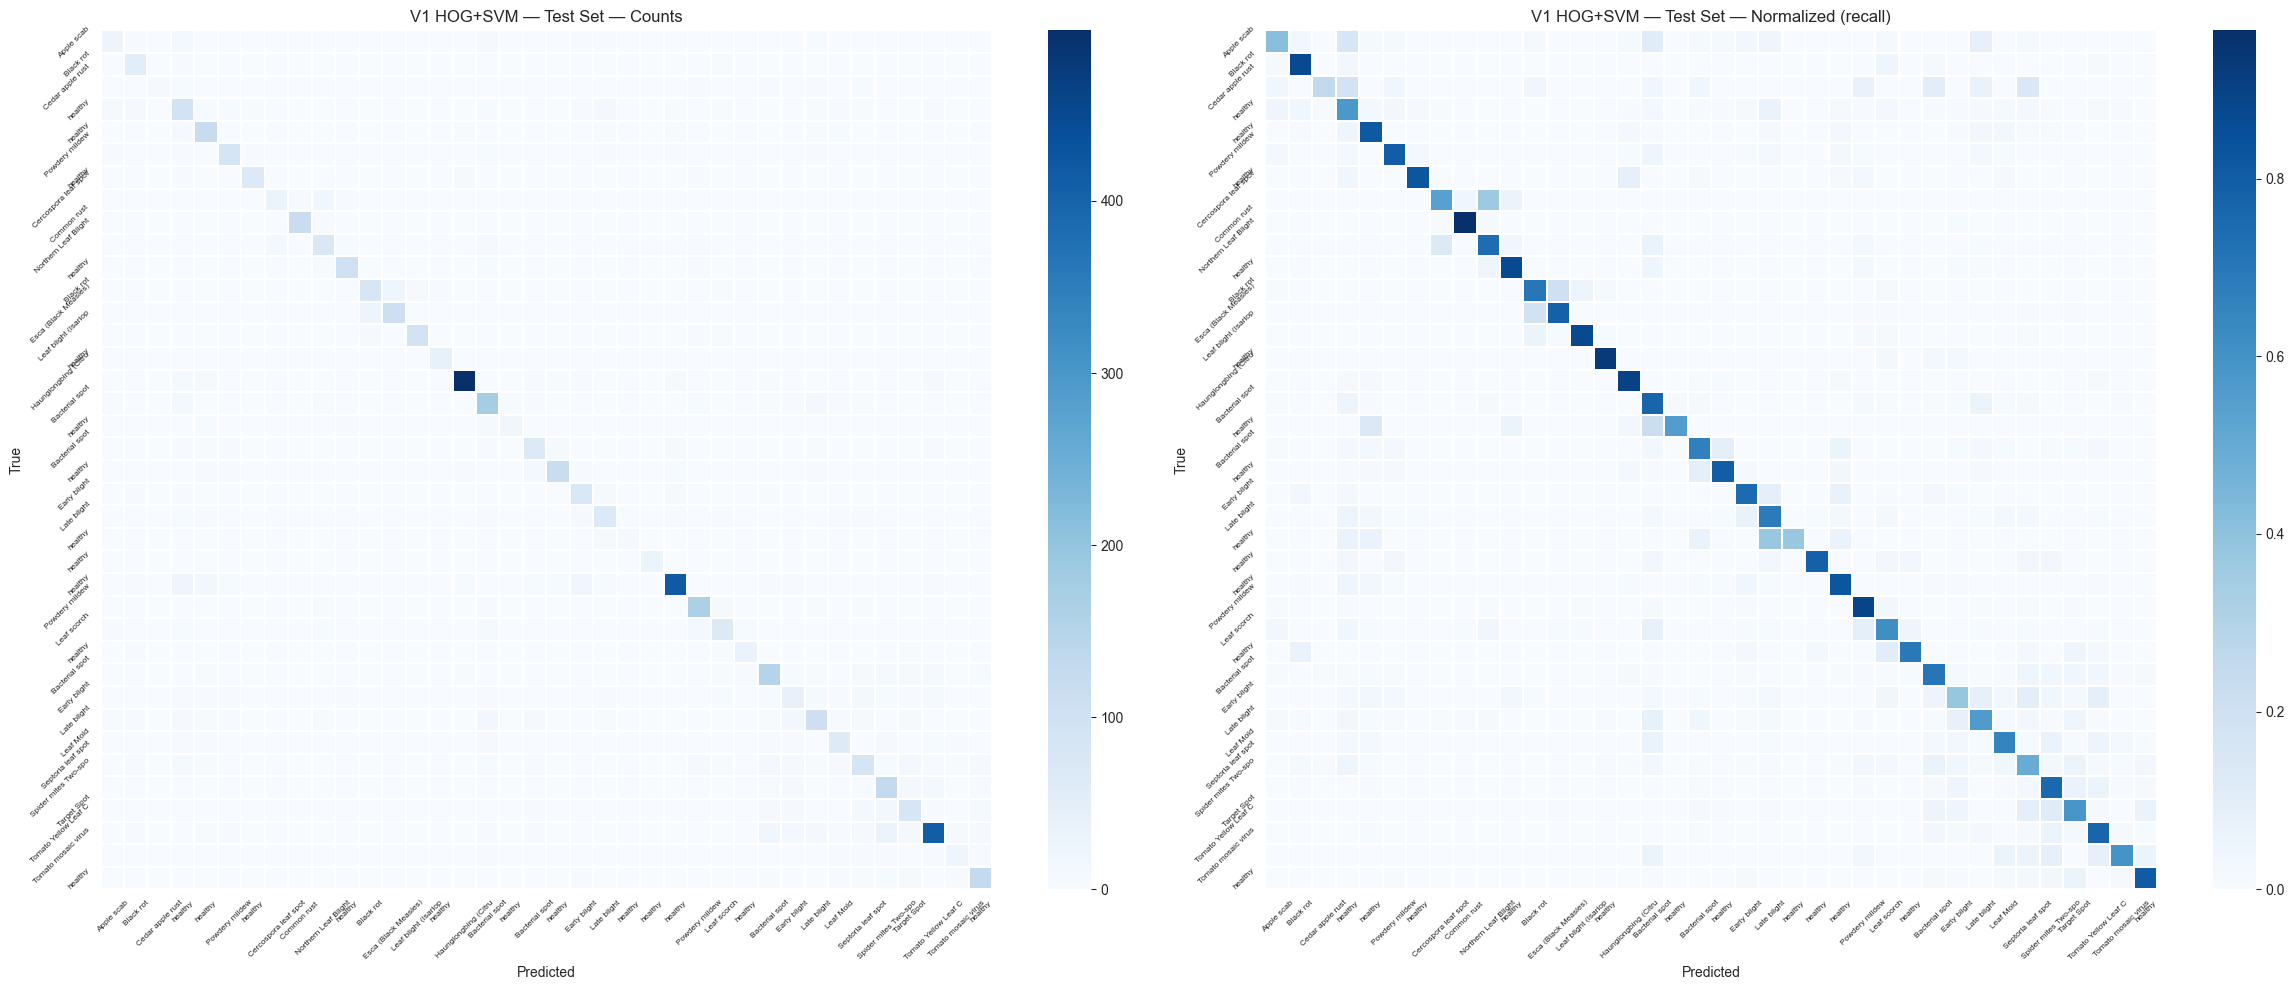

💾 Plot saved: results/plots/v1_confusion_matrix.png


In [14]:
def plot_confusion_matrix(cm, class_names, title, save_path):
    # Normalize by row (per-class recall)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    for ax, data, fmt, subtitle in [
        (axes[0], cm,      'd',    'Counts'),
        (axes[1], cm_norm, '.2f',  'Normalized (recall)')
    ]:
        sns.heatmap(
            data, ax=ax, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot=(cm.shape[0] <= 15), fmt=fmt, linewidths=0.3
        )
        ax.set_title(f'{title} — {subtitle}', fontsize=12)
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='both', labelsize=6, rotation=45)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Plot saved: {Path(save_path).relative_to(ROOT)}')

short_names = [c.split('___')[1].replace('_', ' ')[:20] if '___' in c else c[:20] for c in classes]

plot_confusion_matrix(
    np.array(test_metrics['confusion_matrix']),
    short_names,
    title='V1 HOG+SVM — Test Set',
    save_path=PLOTS_DIR / 'v1_confusion_matrix.png'
)

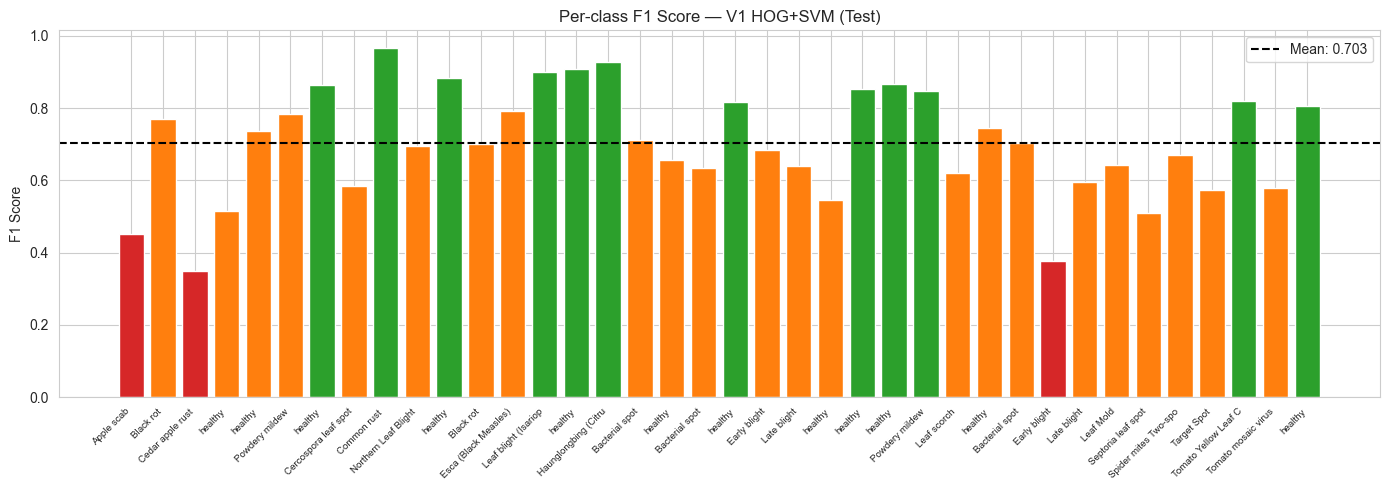


Classes with the lowest F1:
  Apple___Cedar_apple_rust                            F1=0.350
  Tomato___Early_blight                               F1=0.376
  Apple___Apple_scab                                  F1=0.452
  Tomato___Septoria_leaf_spot                         F1=0.509
  Apple___healthy                                     F1=0.515


In [15]:
# Per-class F1 — useful to spot hard classes
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#d62728' if v < 0.5 else '#2ca02c' if v >= 0.8 else '#ff7f0e' for v in f1_per_class]
bars = ax.bar(range(NUM_CLASSES), f1_per_class, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score — V1 HOG+SVM (Test)')
ax.axhline(y=np.mean(f1_per_class), color='black', linestyle='--', label=f'Mean: {np.mean(f1_per_class):.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'v1_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Worst classes
worst_idx = np.argsort(f1_per_class)[:5]
print('\nClasses with the lowest F1:')
for i in worst_idx:
    print(f'  {classes[i]:<50s}  F1={f1_per_class[i]:.3f}')

In [16]:
print('=' * 70)
print('  V1 HOG + SVM — Final Summary')
print('=' * 70)
print(f'  Train samples used   : {len(X_train):,} / {len(train_paths):,}')
print(f'  Feature dim (HOG)    : {extractor.feature_dim}')
print(f'  Training time        : {train_time:.1f}s')
print()
for split, m in [('Val ', val_metrics), ('Test', test_metrics)]:
    print(f'  [{split}] Acc={m["accuracy"]:.4f}  '
          f'F1(wgt)={m["f1"]:.4f}  F1(macro)={m["f1_macro"]:.4f}')
print()
print('  Model    : results/models/v1_hog_svm/svm_model.pkl')
print('  Metrics  : results/metrics/v1_metrics.json')
print('=' * 70)
print('Continue with: 02_v2_custom_cnn.ipynb')

  V1 HOG + SVM — Final Summary
  Train samples used   : 43,443 / 43,443
  Feature dim (HOG)    : 3780
  Training time        : 1104.3s

  [Val ] Acc=0.7475  F1(wgt)=0.7480  F1(macro)=0.6929
  [Test] Acc=0.7474  F1(wgt)=0.7490  F1(macro)=0.7032

  Model    : results/models/v1_hog_svm/svm_model.pkl
  Metrics  : results/metrics/v1_metrics.json
Continue with: 02_v2_custom_cnn.ipynb


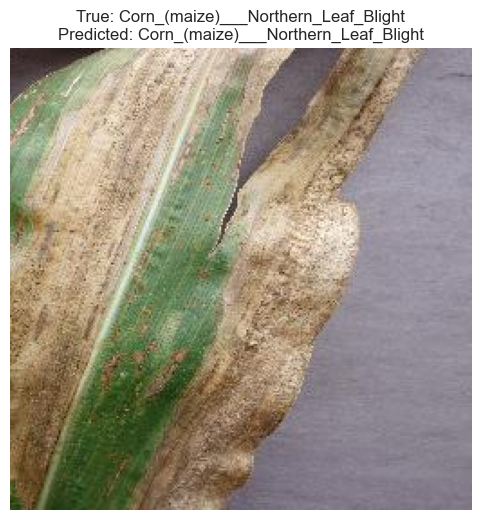

Image: /Users/marco/Documents/repos/ComputerVisionProject/data/processed/test/Corn_(maize)___Northern_Leaf_Blight/f69b1b10-dd7f-44c0-b084-1959316e4f2a___RS_NLB 3955 copy 2.jpg
True class : Corn_(maize)___Northern_Leaf_Blight
Predicted class: Corn_(maize)___Northern_Leaf_Blight


In [17]:
# Pick a random image from the test set
t = len(test_paths)
if t == 0:
    raise ValueError('The test set is empty, there are no images to show.')

sample_idx = np.random.randint(t)
sample_path = test_paths[sample_idx]
true_class = le.inverse_transform([test_labels[sample_idx]])[0]

feature = extractor.extract(sample_path).reshape(1, -1)
pred_idx = svm.predict(feature)[0]
pred_class = le.inverse_transform([pred_idx])[0]

img = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"True: {true_class}\nPredicted: {pred_class}", fontsize=12)
plt.axis('off')
plt.show()

print(f"Image: {sample_path}")
print(f"True class : {true_class}")
print(f"Predicted class: {pred_class}")